In [1]:
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# --------------------------
# 1. Load Dataset
# --------------------------
df = pd.read_csv("hf://datasets/KathiS/new_preprocessed_dataset/new_cleaned.csv")
print("Loaded dataset:", df.shape)

# --------------------------
# 2. Select Important Features
# --------------------------
important_features = [
    "Flow_Duration",
    "Init_Bwd_Win_Byts",
    "Dst_Port",
    "Idle_Mean",
    "Flow_IAT_Min",
    "Flow_Pkts/s",
    "Pkt_Len_Max",
    "ACK_Flag_Cnt",
    "Fwd_Pkt_Len_Max",
    "Bwd_Header_Len",
    "TotLen_Bwd_Pkts",
    "Fwd_Pkts/s",
    "Flow_Byts/s",
    "Bwd_Pkt_Len_Max",
    "Bwd_Pkts/s",
    "TotLen_Fwd_Pkts",
    "Flow_IAT_Max",
    "Fwd_Pkt_Len_Min",
    "Bwd_Pkt_Len_Mean",
    "Pkt_Len_Std",
    "SYN_Flag_Cnt",
    "Pkt_Len_Mean"
]

label_column = "Label"
df_selected = df[important_features + [label_column]]

# --------------------------
# 3. Separate X and y
# --------------------------
X = df_selected[important_features]
y = df_selected[label_column]

# --------------------------
# 4. Define target Normal size (controlled under-sampling)
# --------------------------
class_counts = y.value_counts()
normal_count = class_counts["Normal"]

# Example: keep Normal at 200,000 samples (adjust if needed)
TARGET_NORMAL = min(normal_count, 200_000)

print(f"Target Normal samples after under-sampling: {TARGET_NORMAL}")

# Under-sample ONLY Normal
under_strategy = {"Normal": TARGET_NORMAL}

# SMOTE all attacks up to TARGET_NORMAL
smote_strategy = {
    cls: TARGET_NORMAL
    for cls, cnt in class_counts.items()
    if cls != "Normal" and cnt < TARGET_NORMAL
}

print("Under-sampling strategy:", under_strategy)
print("SMOTE strategy:", smote_strategy)

pipeline = Pipeline([
    ("under", RandomUnderSampler(
        sampling_strategy=under_strategy,
        random_state=42
    )),
    ("smote", SMOTE(
        sampling_strategy=smote_strategy,
        random_state=42
    ))
])

X_bal, y_bal = pipeline.fit_resample(X, y)

print("Final class distribution:")
print(y_bal.value_counts())

# --------------------------
# 5. Feature Scaling
# --------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

final_df = pd.DataFrame(X_scaled, columns=important_features)
final_df["Label"] = y_bal.values

# --------------------------
# 6. Save Final Dataset
# --------------------------
download_path = os.path.join(
    os.path.expanduser("~"),
    "Downloads",
    "Final_Preprocessed_UnderSMOTE_Normal_Controlled.csv"
)

final_df.to_csv(download_path, index=False)

print("\nFinal dataset saved to:")
print(download_path)
print("Final shape:", final_df.shape)


Loaded dataset: (625783, 70)
Target Normal samples after under-sampling: 40073
Under-sampling strategy: {'Normal': np.int64(40073)}
SMOTE strategy: {'MITM ARP Spoofing': np.int64(40073), 'Scan Hostport': np.int64(40073)}
Final class distribution:
Label
Mirai-UDP Flooding       183554
Mirai-Hostbruteforceg    121181
DoS-Synflooding           59391
Mirai-HTTP Flooding       55818
Mirai-Ackflooding         55124
Scan Port OS              53073
MITM ARP Spoofing         40073
Normal                    40073
Scan Hostport             40073
Name: count, dtype: int64

Final dataset saved to:
C:\Users\Hp\Downloads\Final_Preprocessed_UnderSMOTE_Normal_Controlled.csv
Final shape: (648360, 23)


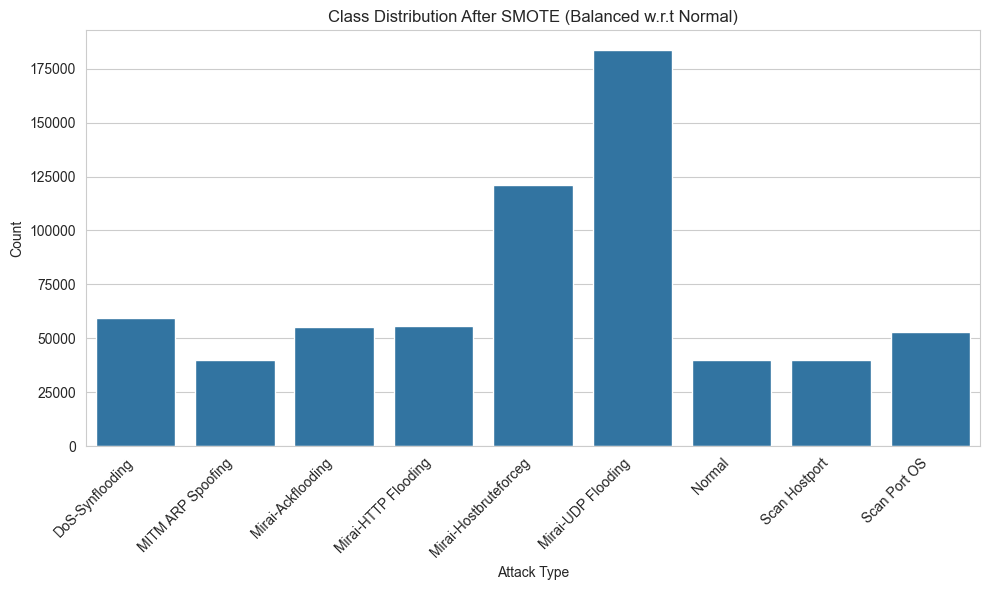

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(data=final_df, x="Label")
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution After SMOTE (Balanced w.r.t Normal)")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_12576\2311812209.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


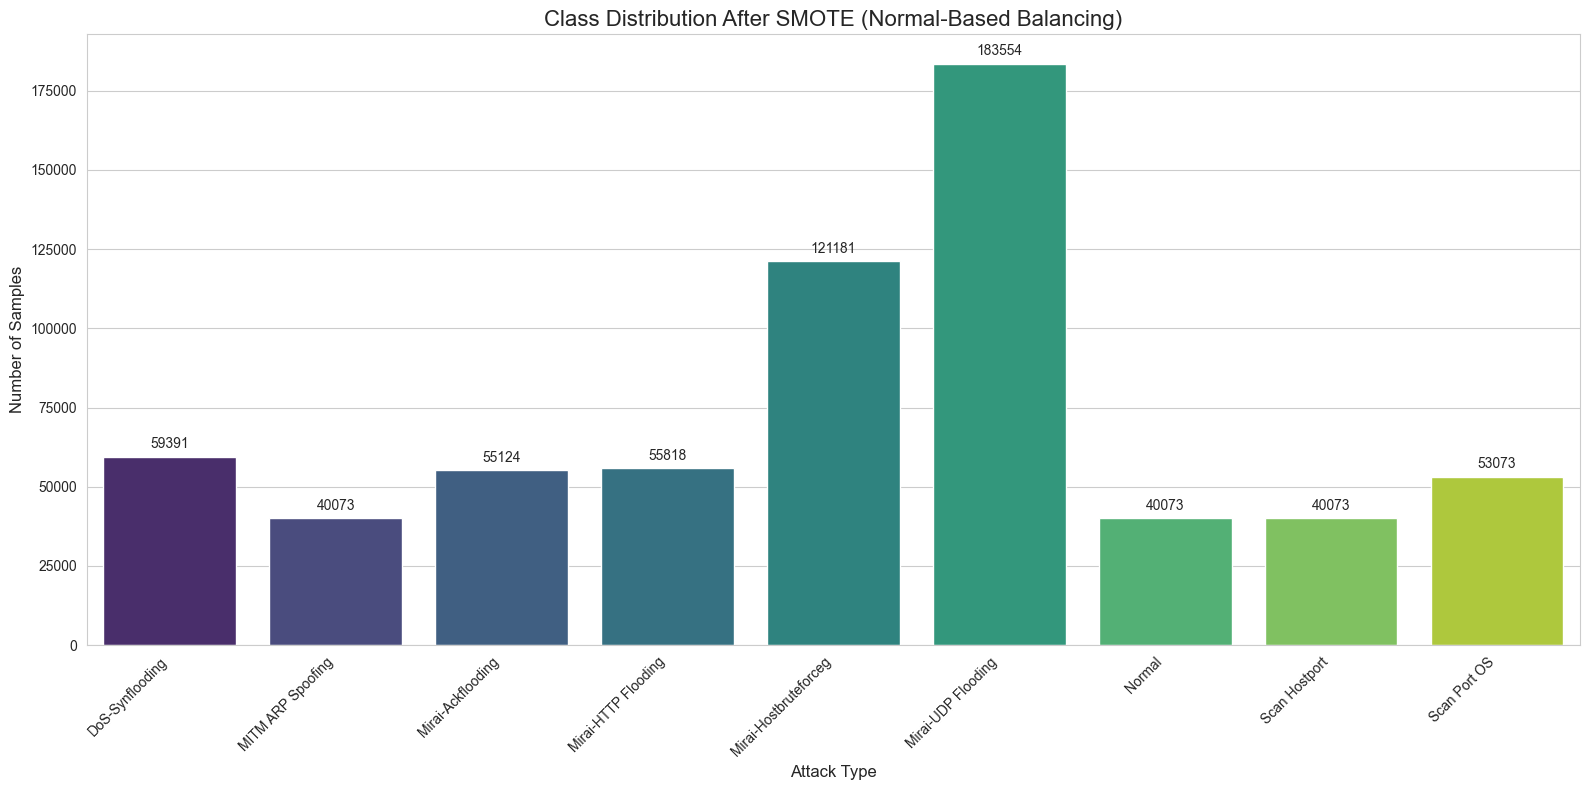

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(16, 8))
ax = sns.countplot(
    data=final_df,
    x="Label",
    palette="viridis"
)

# ---- FIX TICK LABELS MANUALLY ----
labels = final_df["Label"].unique()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
# ----------------------------------

plt.title("Class Distribution After SMOTE (Normal-Based Balancing)", fontsize=16)
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

# Add bar values
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)

plt.tight_layout()
plt.show()


In [4]:

import pandas as pd
import numpy as np
import os
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import shap
import optuna
import warnings
warnings.filterwarnings("ignore")

# Paths
DATA_PATH = r"C:\Users\Hp\Downloads\nom_r\Final_Preprocessed_UnderSMOTE_Normal_Controlled.csv"   # Change to your dataset path
RESULTS_DIR = r"C:\Users\Hp\Downloads\nom_r\res"
SHAP_DIR = os.path.join(RESULTS_DIR, "shap_plots")
os.makedirs(SHAP_DIR, exist_ok=True)


In [6]:
# Section 2: Load Dataset
df = pd.read_csv(DATA_PATH)

# Encode labels if they are categorical
if df['Label'].dtype == 'object':
    le = LabelEncoder()
    df['Label'] = le.fit_transform(df['Label'])

# Separate features and target
X = df.drop('Label', axis=1)
y = df['Label']

print("Dataset Shape:", df.shape)
print("Feature Columns:", X.columns.tolist())


Dataset Shape: (648360, 23)
Feature Columns: ['Flow_Duration', 'Init_Bwd_Win_Byts', 'Dst_Port', 'Idle_Mean', 'Flow_IAT_Min', 'Flow_Pkts/s', 'Pkt_Len_Max', 'ACK_Flag_Cnt', 'Fwd_Pkt_Len_Max', 'Bwd_Header_Len', 'TotLen_Bwd_Pkts', 'Fwd_Pkts/s', 'Flow_Byts/s', 'Bwd_Pkt_Len_Max', 'Bwd_Pkts/s', 'TotLen_Fwd_Pkts', 'Flow_IAT_Max', 'Fwd_Pkt_Len_Min', 'Bwd_Pkt_Len_Mean', 'Pkt_Len_Std', 'SYN_Flag_Cnt', 'Pkt_Len_Mean']


In [9]:
# Section 3: Utility Functions

# 1. Metrics calculation
def compute_metrics(y_true, y_pred, y_prob=None, classes=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    # Only compute ROC AUC if y_prob is valid
    roc_auc = None
    if y_prob is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
        except ValueError:
            print("Skipping ROC AUC for this model/fold due to class mismatch.")
    
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm, "roc_auc": roc_auc}


# 2. Plot Confusion Matrix
def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# 3. Save model
def save_model(model, filename):
    with open(filename, "wb") as f:
        pickle.dump(model, f)

# 4. SHAP Explainability
def shap_explain(model, X, model_name="model"):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X, show=False)
    plt.savefig(os.path.join(SHAP_DIR, f"{model_name}_shap_summary.png"))
    plt.close()


In [10]:
# Section 5: k-Fold Training
def train_models_kfold(X, y, models_dict, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_metrics = {name: [] for name in models_dict.keys()}
    fold_num = 1

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        for name, model in models_dict.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            y_prob = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None
            metrics = compute_metrics(y_val, y_pred, y_prob)
            metrics['fold'] = fold_num
            all_metrics[name].append(metrics)
        fold_num += 1
    return all_metrics


In [11]:
# json serializable conversion
import numpy as np
import json

def make_json_serializable(metrics_all):
    serializable = {}
    for model, folds in metrics_all.items():
        serializable[model] = []
        for fold in folds:
            fold_copy = {}
            for k, v in fold.items():
                if isinstance(v, np.ndarray):
                    fold_copy[k] = v.tolist()  # convert array to list
                elif isinstance(v, (np.float64, np.float32)):
                    fold_copy[k] = float(v)    # convert to float
                elif isinstance(v, (np.int64, np.int32)):
                    fold_copy[k] = int(v)      # convert to int
                else:
                    fold_copy[k] = v
            serializable[model].append(fold_copy)
    return serializable



In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_metrics = train_models_kfold(X, y, {"XGBoost": xgb_model}, k=8)

# Convert metrics to JSON-serializable format
xgb_metrics = make_json_serializable(xgb_metrics)
with open(os.path.join(RESULTS_DIR, "xgb_metrics.json"), "w") as f:
    json.dump(xgb_metrics, f, indent=4)

# Save the trained XGBoost model
# save_model(xgb_model, os.path.join(RESULTS_DIR, "xgb_initial_model.pkl"))
print("XGBoost initial run done. Metrics saved in xgb_metrics.json")


XGBoost initial run done. Metrics saved in xgb_metrics.json


In [13]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(random_state=42)
lgb_metrics = train_models_kfold(X, y, {"LightGBM": lgb_model}, k=8)

# Convert metrics to JSON-serializable format
lgb_metrics = make_json_serializable(lgb_metrics)
with open(os.path.join(RESULTS_DIR, "lgb_metrics.json"), "w") as f:
    json.dump(lgb_metrics, f, indent=4)


print("LightGBM initial run done. Metrics saved in lgb_metrics.json")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4943
[LightGBM] [Info] Number of data points in the train set: 567315, number of used features: 22
[LightGBM] [Info] Start training from score -2.389094
[LightGBM] [Info] Start training from score -2.782286
[LightGBM] [Info] Start training from score -2.465037
[LightGBM] [Info] Start training from score -2.453082
[LightGBM] [Info] Start training from score -1.675873
[LightGBM] [Info] Start training from score -1.263119
[LightGBM] [Info] Start training from score -2.783911
[LightGBM] [Info] Start training from score -2.781888
[LightGBM] [Info] Start training from score -2.504413
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.141817 seconds.
You can set `force_col_wise=true` to remove the overhead